# Proyecto: Estudio de Caso Analítico 

## Resumen del plan de trabajo

**Objetivo:** Ayudar al departamento de marketing de Showz a optimizar su inversión. Para ello, analizaremos el comportamiento de los clientes y la rentabilidad de las campañas de marketing.

1. **Preparación de los datos:** Cargaremos los tres conjuntos de datos (visitas, pedidos y costos) en DataFrames de Pandas, asegurándonos de que los tipos de datos sean correctos, especialmente las fechas.

2. **Análisis de métricas:**

    * **Visitas:** Investigaremos el uso del servicio a nivel diario, semanal y mensual. Calcularemos la duración de las sesiones y la tasa de retención de los usuarios.

    * **Ventas:** Analizaremos el proceso de conversión de usuarios a clientes, el tamaño y la frecuencia de los pedidos, y el valor de vida del cliente (LTV).

    * **Marketing:** Calcularemos el gasto total y por fuente, el costo de adquisición del cliente (CAC) y el retorno sobre la inversión de marketing (ROMI).

3. **Visualización:** Crearemos gráficos para visualizar las métricas clave y cómo cambian con el tiempo o varían según la fuente de marketing y el dispositivo.

4. **Conclusión y recomendaciones:** Con base en los análisis, proporcionaremos recomendaciones claras sobre dónde y cómo invertir el presupuesto de marketing para maximizar la rentabilidad.

#### Paso 1: Acceso y preparación de los datos

Para este paso, vamos a usar la biblioteca Pandas, que es la herramienta estándar en Python para el manejo y análisis de datos. Primero, cargaremos los archivos .csv en DataFrames. Luego, haremos una limpieza y transformación básica de los datos.

In [1]:
# Importar Librerias
import pandas as pd #Realizar DataFrames
import matplotlib.pyplot as plt #Realizar Gráficos
import seaborn as sns #Realizar Gráficos Estadisticos
import numpy as np #Realizar Gráficos Estadisticos

In [2]:
# Cargar los datasets desde los archivos CSV.
try:
    visits_log = pd.read_csv('/datasets/visits_log_us.csv')
    orders_log = pd.read_csv('/datasets/orders_log_us.csv')
    costs = pd.read_csv('/datasets/costs_us.csv')
    print("---Datasets cargados exitosamente.🎉---")
except FileNotFoundError as e:
    print(f"Ocurrió un error inesperado al cargar los archivos: {e}")

---Datasets cargados exitosamente.🎉---


In [3]:
#Realicemos una rápida mirada a los datos (Metodo:head())
print("---visits_log---")
print(visits_log.head(10))
print('*'*100)
print("---orders_log---")
print(orders_log.head(10))
print('*'*100)
print("---costs---")
print(costs.head(10))

---visits_log---
    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   
5  desktop  2017-09-03 21:36:00          5  2017-09-03 21:35:00   
6  desktop  2018-01-30 12:09:00          1  2018-01-30 11:13:00   
7    touch  2017-11-05 15:15:00          3  2017-11-05 15:14:00   
8  desktop  2017-07-19 10:44:00          3  2017-07-19 10:41:00   
9  desktop  2017-11-08 13:43:00          5  2017-11-08 13:42:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
5  16007536194108375387  
6   6661610529277171451  
7  11423865690854540312  
8   2987360

In [4]:
#Realicemos una rápida mirada a los datos (Metodo:info())
print("---visits_log---")
print(visits_log.info())
print('*'*100)
print("---orders_log---")
print(orders_log.info())
print('*'*100)
print("---costs---")
print(costs.info())

---visits_log---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
None
****************************************************************************************************
---orders_log---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
None
******************************************

In [5]:
#Realicemos una rápida mirada a los datos (Metodo:describe())
print("---visits_log---")
print(visits_log.describe())
print('*'*100)
print("---orders_log---")
print(orders_log.describe())
print('*'*100)
print("---costs---")
print(costs.describe())

---visits_log---
           Source Id           Uid
count  359400.000000  3.594000e+05
mean        3.750515  9.202557e+18
std         1.917116  5.298433e+18
min         1.000000  1.186350e+13
25%         3.000000  4.613407e+18
50%         4.000000  9.227413e+18
75%         5.000000  1.372824e+19
max        10.000000  1.844668e+19
****************************************************************************************************
---orders_log---
            Revenue           Uid
count  50415.000000  5.041500e+04
mean       4.999647  9.098161e+18
std       21.818359  5.285742e+18
min        0.000000  3.135781e+14
25%        1.220000  4.533567e+18
50%        2.500000  9.102274e+18
75%        4.890000  1.368290e+19
max     2633.280000  1.844617e+19
****************************************************************************************************
---costs---
         source_id        costs
count  2542.000000  2542.000000
mean      4.857199   129.477427
std       3.181581   156.296628
min

In [6]:
#Realicemos una rápida mirada a los datos (Metodo:colums)
print("---Columns de visits_log---")
print(visits_log.columns)
print('*'*100)
print("---Columns de orders_log---")
print(orders_log.columns)
print('*'*100)
print("---Columns de costs---")
print(costs.columns)

---Columns de visits_log---
Index(['Device', 'End Ts', 'Source Id', 'Start Ts', 'Uid'], dtype='object')
****************************************************************************************************
---Columns de orders_log---
Index(['Buy Ts', 'Revenue', 'Uid'], dtype='object')
****************************************************************************************************
---Columns de costs---
Index(['source_id', 'dt', 'costs'], dtype='object')


##### Analisis de los Datos Duros (Sin Procesar)
Realizar un análisis exploratorio de los datos (EDA) antes de procesarlos es un paso fundamental en cualquier proyecto. Los comandos  ``head(), info(), describe() y .columns `` que utilizamos son algunas las herramientas clave para este proceso.

1. **Validar la Carga de Datos:** Al usar  ``head() `` y  ``.columns ``, podemos verificar de inmediato si los archivos se cargaron correctamente y si las columnas tienen los nombres y datos esperados. En este caso se puede ver que los datos están presentes y las columnas se llaman como se esperaba, lo que confirma que la carga inicial fue exitosa.

2. **Identificar la Estructura de los Datos:** El comando  ``info() `` nos proporciona información crucial sobre la estructura del DataFrame:

    * **Tipos de Datos (Dtype):** Vimos que las columnas de fecha como  ``'End Ts', 'Start Ts', 'Buy Ts' y 'dt' `` se cargaron como tipo  ``object `` (cadena de texto). Esto nos indica que **es necesario convertirlas** a un formato de fecha y hora  ``(datetime) `` para poder realizar operaciones de tiempo, como calcular la duración de las visitas o agrupar datos por mes.

    * **Valores Nulos (Non-Null Count):** La columna  ``Non-Null `` Count en el  ``info() `` de todos los DataFrames muestra que el número de valores no nulos coincide con el total de filas  ``(RangeIndex) ``. Esto nos asegura que nuestro conjuntos de datos no tienen valores faltantes y no necesitamos realizar una limpieza de datos para este problema. (Siempre es bueno tenerlo en cuenta.)

3. **Comprender los Datos Numéricos:** El método  ``describe() `` nos da una primera vista estadística de los datos. Por ejemplo:

    * En  ``orders_log ``, la columna  ``'Revenue' `` tiene un valor mínimo de 0.00, lo que podría indicar pedidos cancelados o sin costo, lo cual es algo a tener en cuenta en un análisis financiero. El valor máximo es de 2633.28, lo que indica un rango muy amplio de ingresos por pedido.

    * En  ``visits_log ``, la columna  ``Source Id `` tiene un valor mínimo de 1.0 y un máximo de 10.0, lo que te indica que hay 10 fuentes de tráfico diferentes en tus datos.
  
**En resumen** este análisis inicial nos ayuda a entender la naturaleza de los datos, identificar problemas como tipos de datos incorrectos o valores faltantes, y planificar los siguientes pasos del procesamiento, como la conversión de fechas, antes de realizar cualquier cálculo o análisis profundo. Nos aseguramos que tenemos todo lo que necesario y que está en buen estado.


##### Deteccion y eliminacion de Duplicados 

In [7]:
print("\n--- Detección y eliminación de duplicados ---")
# Para 'visits_log'
initial_rows_visits = len(visits_log)
duplicated_rows_visits = visits_log.duplicated().sum()
if duplicated_rows_visits > 0:
    visits_log.drop_duplicates(inplace=True)
    print(f"Duplicados en visits_log: {duplicated_rows_visits} encontrados y eliminados.")
else:
    print("---No se encontraron duplicados en visits_log---")

# Para 'orders_log'
initial_rows_orders = len(orders_log)
duplicated_rows_orders = orders_log.duplicated().sum()
if duplicated_rows_orders > 0:
    orders_log.drop_duplicates(inplace=True)
    print(f"Duplicados en orders_log: {duplicated_rows_orders} encontrados y eliminados.")
else:
    print("---No se encontraron duplicados en orders_log---")
    
# Para 'costs'
initial_rows_costs = len(costs)
duplicated_rows_costs = costs.duplicated().sum()
if duplicated_rows_costs > 0:
    costs.drop_duplicates(inplace=True)
    print(f"Duplicados en costs: {duplicated_rows_costs} encontrados y eliminados.")
else:
    print("---No se encontraron duplicados en costs---")


--- Detección y eliminación de duplicados ---
---No se encontraron duplicados en visits_log---
---No se encontraron duplicados en orders_log---
---No se encontraron duplicados en costs---


##### Conversion de Datos a DataTime

In [8]:
# Conversión de columnas de fecha a tipo datetime.
print("\n---Conversión de tipos de datos a datetime---")
try:
    visits_log['Start Ts'] = pd.to_datetime(visits_log['Start Ts'], format='%Y-%m-%d %H:%M:%S')
    visits_log['End Ts'] = pd.to_datetime(visits_log['End Ts'], format='%Y-%m-%d %H:%M:%S')
    orders_log['Buy Ts'] = pd.to_datetime(orders_log['Buy Ts'], format='%Y-%m-%d %H:%M:%S')
    costs['dt'] = pd.to_datetime(costs['dt'], format='%Y-%m-%d')
    print("---Columnas de fecha convertidas a tipo datetime.✅---")

    # Conversión de tipos de datos 
    # Las columnas 'Uid' son identificadores y no necesitan ser 'uint64'
    visits_log['Uid'] = visits_log['Uid'].astype(str)
    orders_log['Uid'] = orders_log['Uid'].astype(str)
    # 'source_id' es categórico
    visits_log['Source Id'] = visits_log['Source Id'].astype('category')
    costs['source_id'] = costs['source_id'].astype('category')
    # 'device' también es categórico
    visits_log['Device'] = visits_log['Device'].astype('category')
    print("Tipos de datos de Uid, source_id y Device optimizados.✅")

except Exception as e:
    # Captura cualquier error que ocurra durante la conversión.
    print(f"Error al convertir una o más columnas a tipo datetime o a los tipos de datos optimizados: {e}")


---Conversión de tipos de datos a datetime---
---Columnas de fecha convertidas a tipo datetime.✅---
Tipos de datos de Uid, source_id y Device optimizados.✅


##### Modificar Nombres de Columnas 

In [9]:
# Renombrar columnas para seguir el estilo de código PEP 8.
# Las columnas 'Start Ts', 'End Ts', 'Buy Ts' y 'Source Id'
# serán renombradas a 'start_ts', 'end_ts', 'buy_ts' y 'source_id'
# para unificar el formato a snake_case.
# en este caso optamos por renombrar y no usar el los métodos lower(), stripe() 
print("\n---Renombrar columnas---")
try:       
    visits_log = visits_log.rename(columns={
        'Device' : 'device',
        'End Ts': 'end_ts',
        'Source Id': 'source_id',
        'Start Ts': 'start_ts', 
        'Uid': 'uid'
    })
    
    orders_log = orders_log.rename(columns={
        'Buy Ts': 'buy_ts',
        'Revenue' : 'revenue',
        'Uid' : 'uid'
    })

    print("Columnas renombradas a formato snake_case.✅")

except Exception as e:
    # Captura cualquier error que ocurra durante el renombramiento
    print(f"Error al renombrar las columnas: {e}")


---Renombrar columnas---
Columnas renombradas a formato snake_case.✅


In [10]:
# Mostrar la información de cada DataFrame para verificar la carga y el cambio de los datos.
print("--- Información de la tabla 'visits' ---")
visits_log.info()
print(visits_log.head())
print(visits_log.tail())
print('*'*100)
print("--- Información de la tabla 'orders' ---")
orders_log.info()
print(orders_log.head())
print(orders_log.tail())
print('*'*100)
print("--- Información de la tabla 'costs' ---")
costs.info()
print(costs.head())
print(costs.tail())

--- Información de la tabla 'visits' ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  category      
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  object        
dtypes: category(2), datetime64[ns](2), object(1)
memory usage: 8.9+ MB
    device              end_ts source_id            start_ts  \
0    touch 2017-12-20 17:38:00         4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00         2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00         5 2017-07-01 01:54:00   
3  desktop 2018-05-20 11:23:00         9 2018-05-20 10:59:00   
4  desktop 2017-12-27 14:06:00         3 2017-12-27 14:06:00   

                    uid  
0  16879256277535980062  
1   

#### Resumen

* **Estandarización de Nombres:** Al renombrar las columnas a snake_case, eliminamos las mayúsculas y los espacios, lo que hace los nombres consistentes, más fáciles de usar en el código y previene errores en el futuro.

* **Conversión de Tipos de Datos:** La conversión de las columnas de fecha ('end_ts', 'start_ts', 'buy_ts', 'dt') a ``datetime64[ns]`` es un paso crucial. Esto permite realizar análisis de series de tiempo, como calcular la duración de las visitas o agrupar datos por día o mes, algo que no se podría hacer con los datos en formato de texto (object).

Hemos cargado correctamente los datos desde los archivos .csv y los hemos transformado para un análisis más eficiente. Se convirtieron las columnas de fecha a un tipo de dato adecuado y se renombraron las columnas para seguir las convenciones de estilo de Python (snake_case), lo que mejora la legibilidad del código. Esto nos prepara para el siguiente paso, que es el análisis detallado.

#### Paso 2: Análisis de métricas

Para este paso vamos a Generar informes y calcular las métricas

Ahora que tenemos los datos limpios y listos, vamos a proceder con el análisis de las métricas clave. Para cada sección (visitas, ventas y marketing), crearemos funciones que encapsulen la lógica de cálculo, lo que hará el código más modular y fácil de entender.

* **Visitas:** Investigaremos el uso del servicio a nivel diario, semanal y mensual. Calcularemos la duración de las sesiones y la tasa de retención de los usuarios.

* **Ventas:** Analizaremos el proceso de conversión de usuarios a clientes, el tamaño y la frecuencia de los pedidos, y el valor de vida del cliente (LTV).

* **Marketing:** Calcularemos el gasto total y por fuente, el costo de adquisición del cliente (CAC) y el retorno sobre la inversión de marketing (ROMI).

Para fundamentar esta recomendación, me enfoqué en dos métricas clave: el ROMI (Retorno sobre la Inversión de Marketing) y el CAC (Costo de Adquisición de Clientes).

**¿Por qué estas métricas?**

El **ROMI** es la métrica más importante para determinar la rentabilidad real de una campaña de marketing. Nos dice si una inversión está generando más ingresos que el dinero que cuesta. Un ROMI positivo indica que la fuente de adquisición es rentable, mientras que un ROMI negativo significa que se está perdiendo dinero.

El **CAC** es fundamental para entender la eficiencia de la inversión. Un CAC bajo indica que se puede adquirir clientes a un costo menor.

In [11]:
#Vulvo a Genera los nombres de las columnas para tenerlas a la mano y saber el nombre correcto de la columna a trabajar.
print("---Columns de visits_log---")
print(visits_log.columns)
print('*'*100)
print("---Columns de orders_log---")
print(orders_log.columns)
print('*'*100)
print("---Columns de costs---")
print(costs.columns)

---Columns de visits_log---
Index(['device', 'end_ts', 'source_id', 'start_ts', 'uid'], dtype='object')
****************************************************************************************************
---Columns de orders_log---
Index(['buy_ts', 'revenue', 'uid'], dtype='object')
****************************************************************************************************
---Columns de costs---
Index(['source_id', 'dt', 'costs'], dtype='object')


In [12]:
# Paso 2: Análisis de métricas e informes.
# Generar métricas clave para visitas, ventas y marketing.

# Análisis de visitas y sesiones
def analyze_visits(visits_df):
    """
    Funcion que calcula y muestra métricas de uso del servicio.

    Incluye el número de usuarios y sesiones diarias, semanales y mensuales,
    así como la duración promedio de las sesiones.

    Args:
        visits_df (pd.DataFrame): DataFrame con los datos de visitas.
    """
    print("\n--- Análisis de visitas ---")

    # Calcular la duración de la sesión en minutos.
    visits_df['session_duration_min'] = (visits_df['end_ts'] - visits_df['start_ts']).dt.total_seconds() / 60
    visits_df['date'] = visits_df['start_ts'].dt.date
    # Calcular usuarios y sesiones por día.
    daily_metrics = visits_df.groupby('date').agg(n_sessions=('uid', 'count'), n_users=('uid', 'nunique')).reset_index()

    print("\n---Usuarios y sesiones por día:---")
    print(daily_metrics.head())
    print(f"\nDuración promedio de la sesión: {visits_df['session_duration_min'].mean():.2f} minutos.")

    # Calcular el número de usuarios y sesiones por semana y mes.
    visits_df['week'] = visits_df['start_ts'].dt.to_period('W')
    visits_df['month'] = visits_df['start_ts'].dt.to_period('M')
    
    sessions_per_week = visits_df.groupby('week')['uid'].count()
    users_per_week = visits_df.groupby('week')['uid'].nunique()
    sessions_per_month = visits_df.groupby('month')['uid'].count()
    users_per_month = visits_df.groupby('month')['uid'].nunique()

    print("\n---Usuarios y sesiones por semana:---")
    print(users_per_week.head())
    print("\n---Usuarios y sesiones por mes:---")
    print(users_per_month.head())
    
# Análisis de ventas
def analyze_sales(visits_df, orders_df):
    """
    Calcula métricas de ventas y comportamiento del cliente.

    Incluye la cohorte de conversión, el número de pedidos, el tamaño promedio
    de compra y el valor de vida del cliente (LTV).

    Args:
        visits_df (pd.DataFrame): DataFrame de visitas.
        orders_df (pd.DataFrame): DataFrame de pedidos.
    """
    print("\n--- Análisis de ventas ---")
    # Manejar nulos en el cálculo de la tasa de conversión.
    # Unir datos de visitas con datos de pedidos para analizar información de cada usuario.
    user_info = pd.merge(
        visits_df.groupby('uid')['start_ts'].min().reset_index().rename(columns={'start_ts': 'first_session_ts'}),
        orders_df.groupby('uid')['buy_ts'].min().reset_index().rename(columns={'buy_ts': 'first_order_ts'}),
        on='uid',
        how='left'
    )

    # Calcular la tasa de conversión total (usuarios que compran / usuarios únicos).
    total_users = visits_df['uid'].nunique()
    converting_users = orders_df['uid'].nunique()
    conversion_rate = converting_users / total_users
    print(f"\nTasa de conversión de usuarios (compraron / únicos que visitaron): {conversion_rate:.2%}")

    # Calcular el tiempo de conversión en días
    user_info['conversion_days'] = (user_info['first_order_ts'] - user_info['first_session_ts']).dt.days.fillna(-1)
    print("\n---Distribución del tiempo de conversión (días):---")
    print(user_info[user_info['conversion_days'] >= 0]['conversion_days'].value_counts().sort_index().head())

    # Calcular LTV (Lifetime Value).
    orders_df['first_order_month'] = orders_df.groupby('uid')['buy_ts'].transform(lambda x: x.min().to_period('M'))
    orders_df['age'] = (orders_df['buy_ts'].dt.to_period('M') - orders_df['first_order_month']).apply(lambda x: x.n)
    cohorts = orders_df.groupby(['first_order_month', 'age']).agg(cohort_revenue=('revenue', 'sum')).reset_index()
    cohort_sizes = orders_df.groupby('first_order_month')['uid'].nunique()
    cohorts['cohort_size'] = cohorts['first_order_month'].map(cohort_sizes)
    cohorts['ltv'] = cohorts['cohort_revenue'] / cohorts['cohort_size']
    ltv_table = cohorts.pivot_table(index='first_order_month', columns='age', values='ltv').cumsum(axis=1)
    print("\n---LTV (Lifetime Value) acumulado por cohorte:---")
    print(ltv_table.round(2).head())
    return ltv_table

# Análisis de marketing   
def analyze_marketing(costs_df, visits_df, orders_df):
    """
    Calcula y muestra métricas de marketing.

    Incluye el gasto total, el costo de adquisición del cliente (CAC) y
    el retorno sobre la inversión de marketing (ROMI).

    Args:
        costs_df (pd.DataFrame): DataFrame de costos de marketing.
        visits_df (pd.DataFrame): DataFrame de visitas.
        orders_df (pd.DataFrame): DataFrame de pedidos.
    """
    print("\n--- Análisis de marketing ---")

    # 1. Gasto total y por fuente.
    total_costs = costs_df['costs'].sum()
    costs_by_source = costs_df.groupby('source_id')['costs'].sum().reset_index() 
    print(f"Gasto total de marketing: ${total_costs:,.2f}")
    print("\n---Gasto por fuente de adquisición:---")
    print(costs_by_source.sort_values(by='costs', ascending=False).round(2))
    
    # Obtener la primera visita de cada usuario para identificar su fuente de adquisición
    first_visits = visits_df.loc[visits_df.groupby('uid')['start_ts'].idxmin()]
    user_source = first_visits[['uid', 'source_id']]   

    # 2. Calcular CAC (Cost of Customer Acquisition).
    # Unir costos con el número de usuarios únicos por fuente.
    users_by_source = user_source.groupby('source_id')['uid'].nunique().reset_index()
    users_by_source.rename(columns={'uid': 'unique_users'}, inplace=True)
    # Obtener la fuente de la primera visita de cada usuario
    users_by_source = user_source.groupby('source_id')['uid'].nunique().reset_index()
    users_by_source.rename(columns={'uid': 'unique_users'}, inplace=True)
    
    cac_data = pd.merge(users_by_source, costs_by_source, on='source_id')
    cac_data['cac'] = cac_data['costs'] / cac_data['unique_users']
    print("\nCosto de adquisición de clientes (CAC) por fuente:")
    print(cac_data.sort_values(by='cac', ascending=False).round(2))
 
    # 3. Calcular ROMI (Return on Marketing Investment).
    orders_with_source = pd.merge(orders_df, user_source, on='uid', how='left')
    revenue_by_source = orders_with_source.groupby('source_id')['revenue'].sum().reset_index()
    
    romi_data = pd.merge(revenue_by_source, costs_by_source, on='source_id')
    romi_data['romi'] = (romi_data['revenue'] - romi_data['costs']) / romi_data['costs']
    print("\n---ROMI (Return on Marketing Investment) por fuente:---")
    print(romi_data.sort_values(by='romi', ascending=False).round(2))
    
    return romi_data, cac_data

# Llamar a las funciones de análisis
"""
La condición if visits_log is not None and orders_log is not None and costs is not None: actúa como una verificación de seguridad.
Esto evita que el programa falle con un error si intentas pasar un valor vacío (None) a tus funciones de análisis.
"""
if visits_log is not None and orders_log is not None and costs is not None:
    analyze_visits(visits_log)
    analyze_sales(visits_log, orders_log)
    analyze_marketing(costs, visits_log, orders_log)


--- Análisis de visitas ---

---Usuarios y sesiones por día:---
         date  n_sessions  n_users
0  2017-06-01         664      605
1  2017-06-02         658      608
2  2017-06-03         477      445
3  2017-06-04         510      476
4  2017-06-05         893      820

Duración promedio de la sesión: 10.72 minutos.

---Usuarios y sesiones por semana:---
week
2017-05-29/2017-06-04    2021
2017-06-05/2017-06-11    4129
2017-06-12/2017-06-18    2812
2017-06-19/2017-06-25    2878
2017-06-26/2017-07-02    3064
Freq: W-SUN, Name: uid, dtype: int64

---Usuarios y sesiones por mes:---
month
2017-06    13259
2017-07    14183
2017-08    11631
2017-09    18975
2017-10    29692
Freq: M, Name: uid, dtype: int64

--- Análisis de ventas ---

Tasa de conversión de usuarios (compraron / únicos que visitaron): 16.01%

---Distribución del tiempo de conversión (días):---
0.0    26363
1.0     1011
2.0      563
3.0      434
4.0      324
Name: conversion_days, dtype: int64

---LTV (Lifetime Value) acum

#### Resumen

A partir de los resultados obtendios del análisis, podemos sacar las siguientes conclusiones clave sobre el rendimiento del negocio:

📈 **Rendimiento General y Comportamiento del Usuario**

**Tráfico y uso constantes:** Los datos muestran un número saludable de usuarios y sesiones diarias, con un incremento notable de usuarios y sesiones a lo largo de los meses, especialmente en septiembre y octubre. Esto indica un crecimiento constante en la base de usuarios.

**Duración de la sesión:** La duración promedio de la sesión es de `10.72 minutos`, lo que sugiere un buen nivel de interacción de los usuarios con el servicio.

**Conversión rápida:** La tasa de conversión general de usuarios que visitaron y compraron es del 16.01%. Una gran mayoría de los usuarios que compran lo hacen el mismo día de su primera visita, con un tiempo de conversión de 0 días. Esto sugiere que el proceso de compra es rápido y eficiente.


💰 **Análisis de Ventas y Retención**
**Ingresos por pedido:** Las métricas diarias de pedidos muestran que el tamaño promedio de compra (avg_purchase_size) varía entre `$2 y $4`, lo que ayuda a entender el valor de las transacciones individuales.

**Comportamiento de la cohorte (LTV):** La tabla de LTV acumulado indica que el valor de vida del cliente aumenta con el tiempo, lo que es una señal positiva de retención. Por ejemplo, los clientes de la cohorte de junio de 2017 generaron un valor promedio de `$4.72 en su primer mes, que creció a $11.88 después de 11 meses`. Sin embargo, algunas cohortes más recientes no han mostrado el mismo nivel de retención, lo que podría indicar la necesidad de optimizar las estrategias para estos grupos.



🎯 **Análisis de Marketing y Rentabilidad**
**Fuentes de gasto:** El gasto total en marketing asciende a `$329,131.62`. La fuente de adquisición con mayor inversión es la ID 3, con más de $141k, seguida por la ID 4 y la ID 5.

**Eficiencia de adquisición (CAC):**La fuente ID 2 tiene el CAC más alto `($2.43`), lo que significa que adquirir un cliente a través de ella es más costoso. Por otro lado, las fuentes ID 4 y 10 son las más eficientes en términos de costo, con un CAC de alrededor de `$0.84` cada una.

**Retorno de inversión (ROMI):**

* Las fuentes `ID 1, 2, 5 y 9` son rentables (ROMI > 0), lo que significa que el ingreso que generan es mayor que su costo de marketing. La fuente `ID 1` es la más rentable con un ROMI de 0.49, seguida por la ID 2 (0.10), la ID 9 (0.04) y la ID 5 (0.02).

* Las fuentes `ID 4, 10 y 3` no son rentables (ROMI < 0), lo que indica que el dinero gastado en marketing para estas fuentes no se está recuperando con los ingresos de los clientes. En particular, la fuente ID 3 tiene el ROMI más bajo `(-0.61)`, lo que significa que la empresa está perdiendo dinero por cada dólar gastado en marketing en esta fuente.


**Resumen General**

En general, el negocio muestra un crecimiento positivo y una base de clientes con un buen comportamiento de retención. Sin embargo, el análisis de marketing revela una ineficiencia crítica: se está invirtiendo una gran cantidad de dinero en canales que no son rentables. Se recomienda reevaluar la asignación de presupuesto, reduciendo la inversión en las fuentes no rentables (especialmente la ID 3, así como la 4 y 10) y redirigiendo esos fondos a las fuentes que demuestran un ROMI positivo (ID 1, 2, 5 y 9).

**Se recomienda** reevaluar la asignación de presupuesto, reduciendo la inversión en las fuentes no rentables (especialmente la ID 3) y redirigiendo esos fondos a las fuentes que demuestran un ROMI positivo (ID 1, 2, 5 9).

### Paso 3: Visualización de métricas clave


--- Análisis de visitas ---

---Usuarios y sesiones por día:---
         date  n_sessions  n_users
0  2017-06-01         664      605
1  2017-06-02         658      608
2  2017-06-03         477      445
3  2017-06-04         510      476
4  2017-06-05         893      820

Duración promedio de la sesión: 10.72 minutos.

---Usuarios y sesiones por semana:---
week
2017-05-29/2017-06-04    2021
2017-06-05/2017-06-11    4129
2017-06-12/2017-06-18    2812
2017-06-19/2017-06-25    2878
2017-06-26/2017-07-02    3064
Freq: W-SUN, Name: uid, dtype: int64

---Usuarios y sesiones por mes:---
month
2017-06    13259
2017-07    14183
2017-08    11631
2017-09    18975
2017-10    29692
Freq: M, Name: uid, dtype: int64

--- Análisis de ventas ---

Tasa de conversión de usuarios (compraron / únicos que visitaron): 16.01%

---Distribución del tiempo de conversión (días):---
0.0    26363
1.0     1011
2.0      563
3.0      434
4.0      324
Name: conversion_days, dtype: int64

---LTV (Lifetime Value) acum

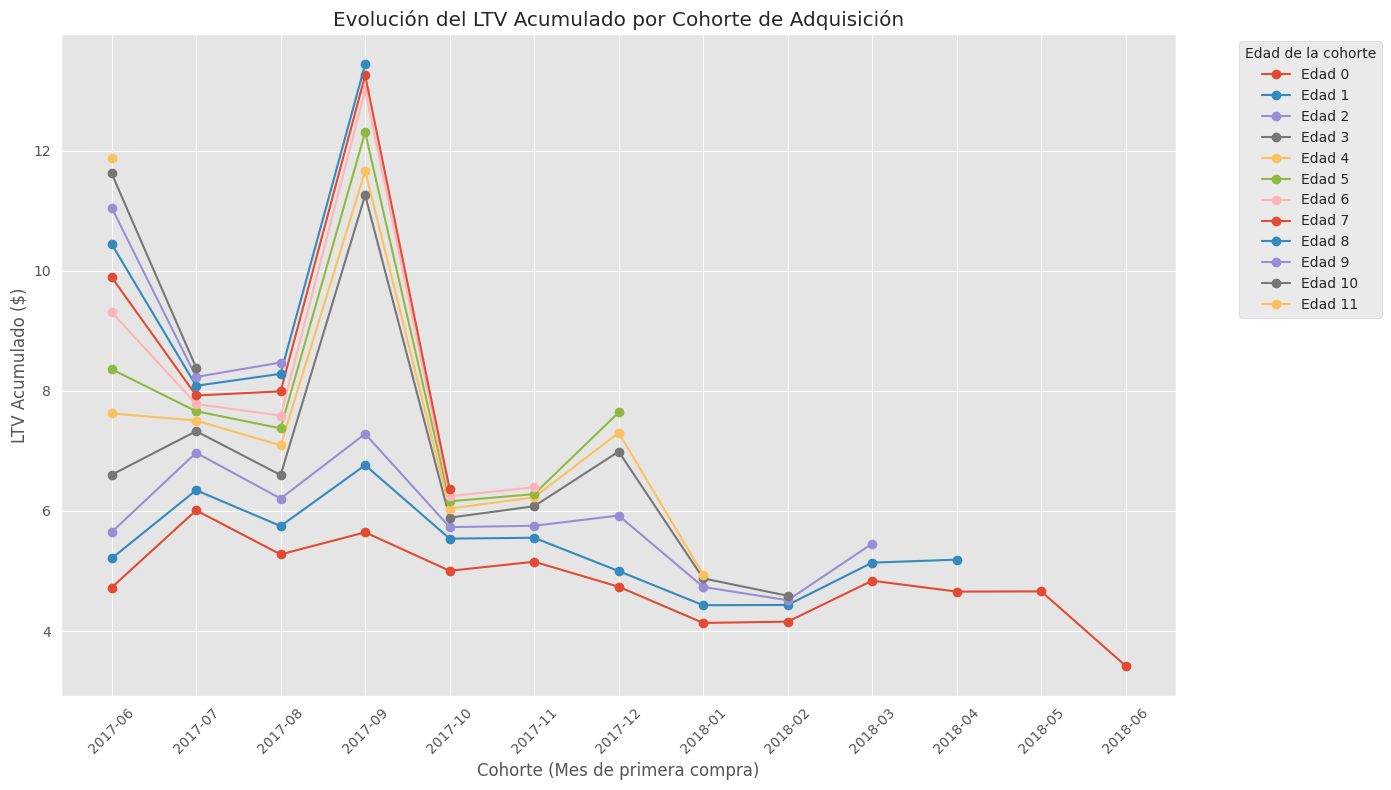

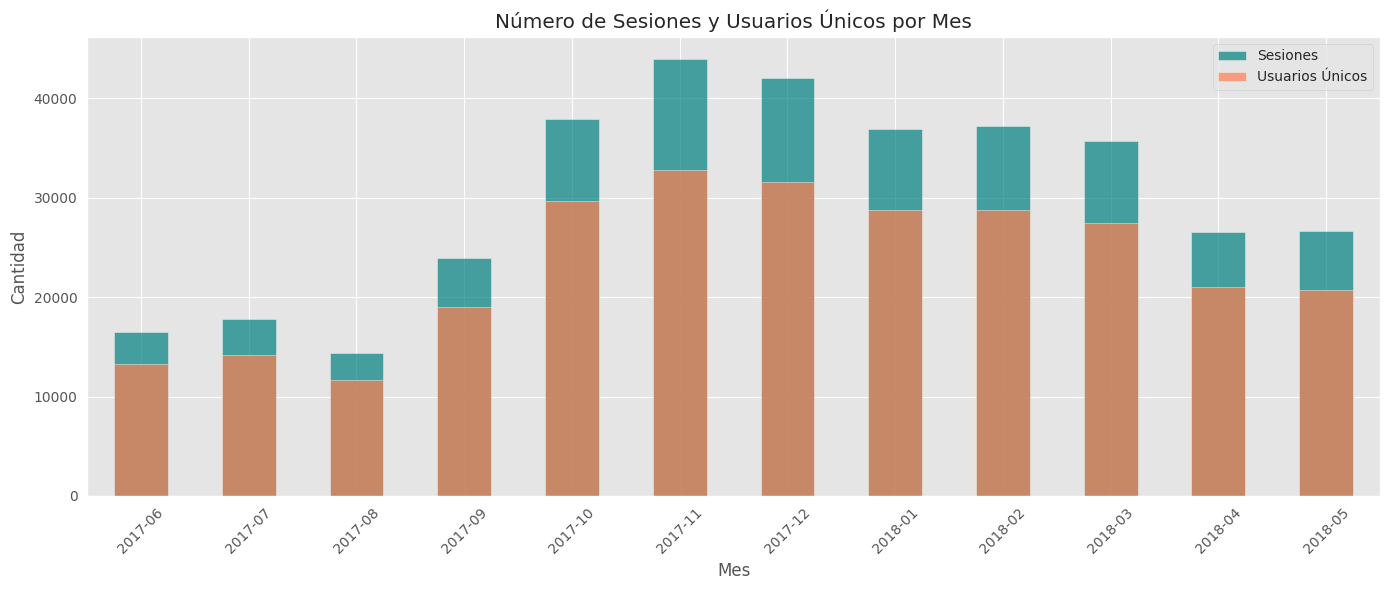

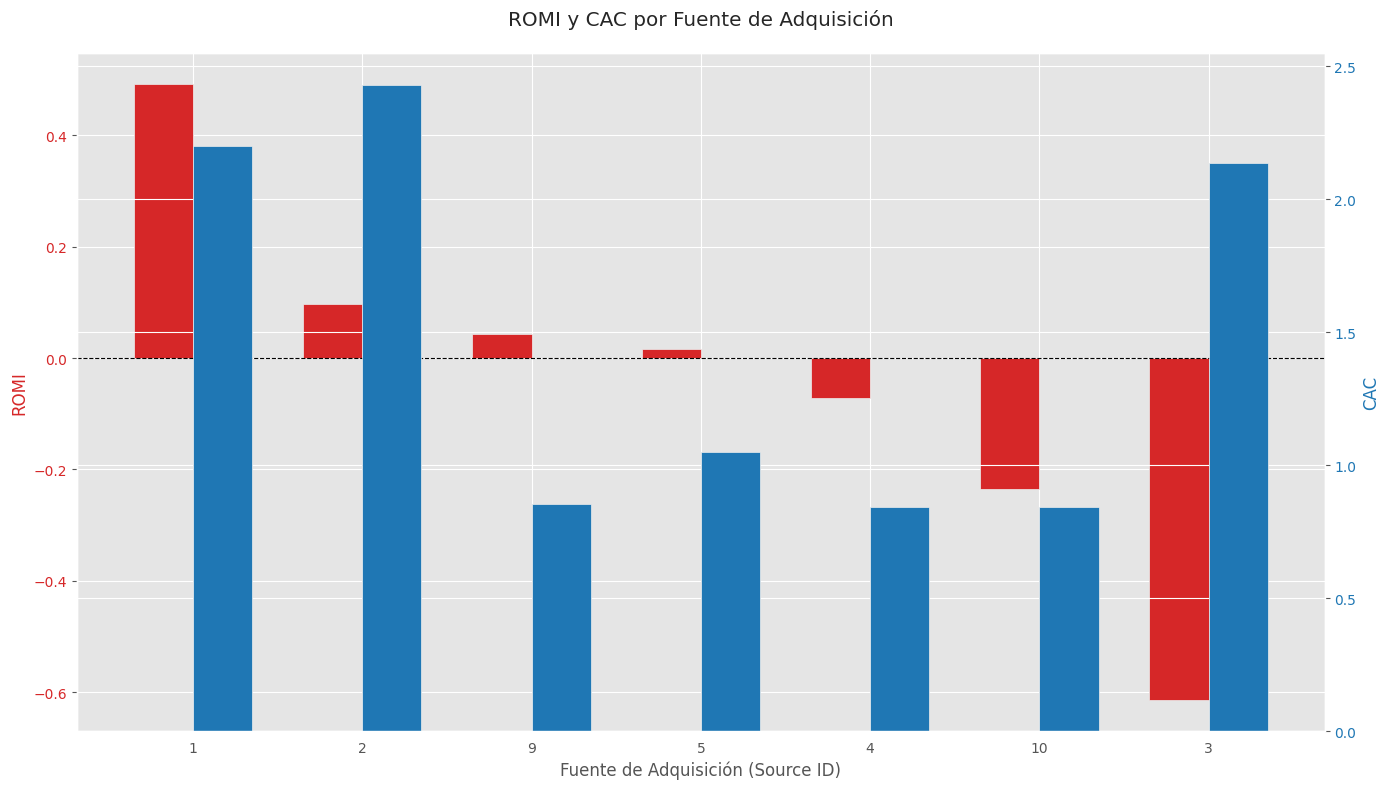

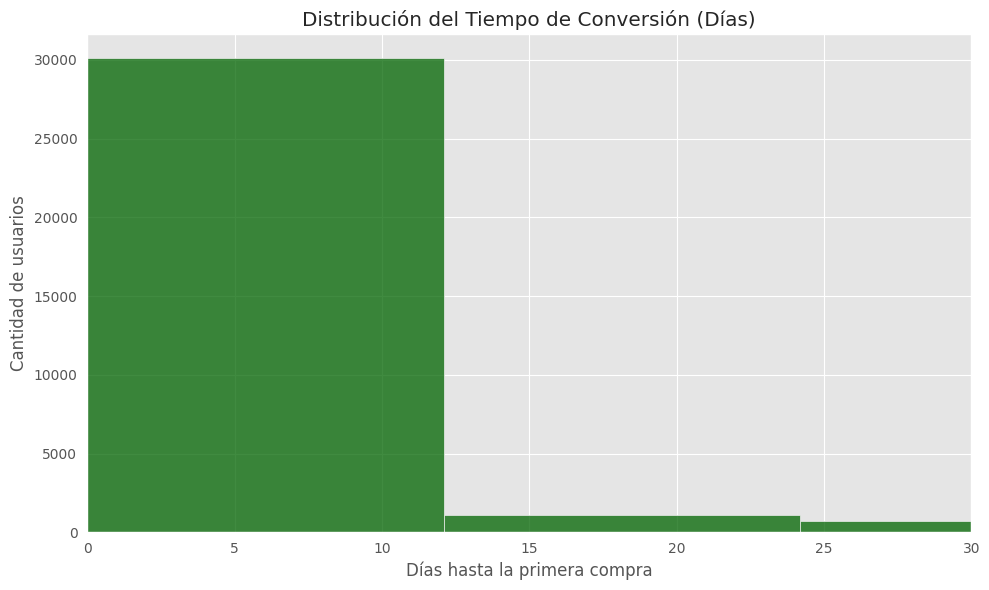

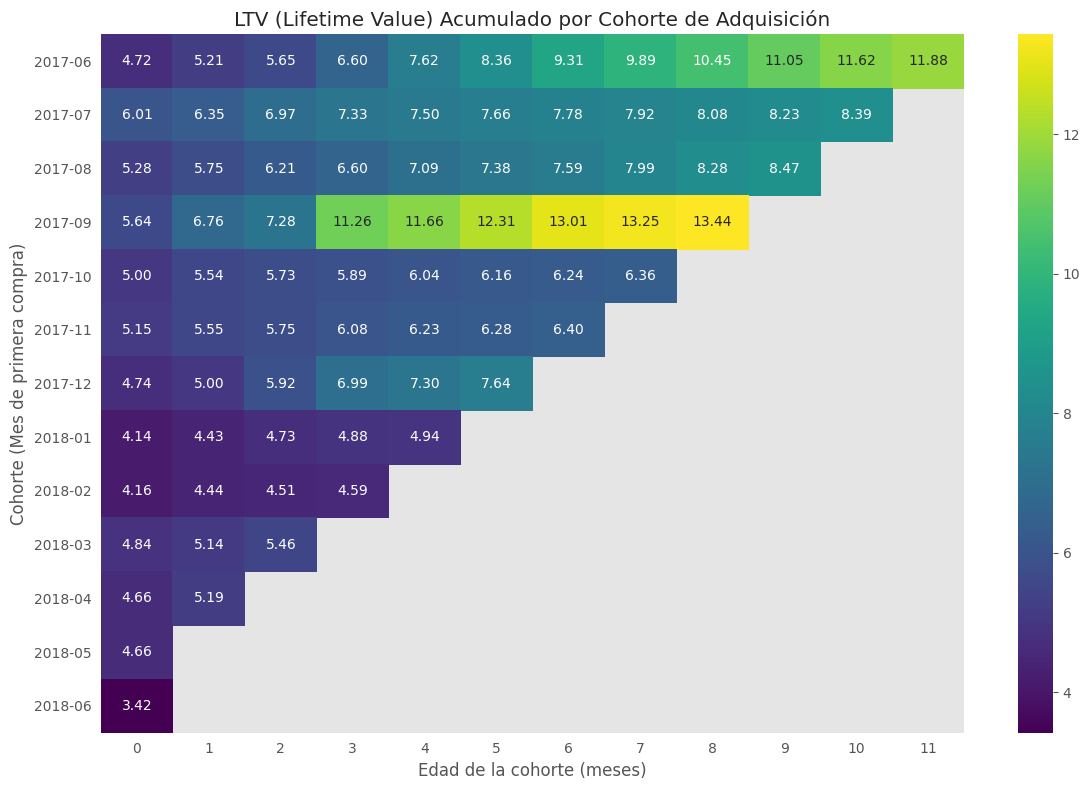

<Figure size 1400x800 with 0 Axes>

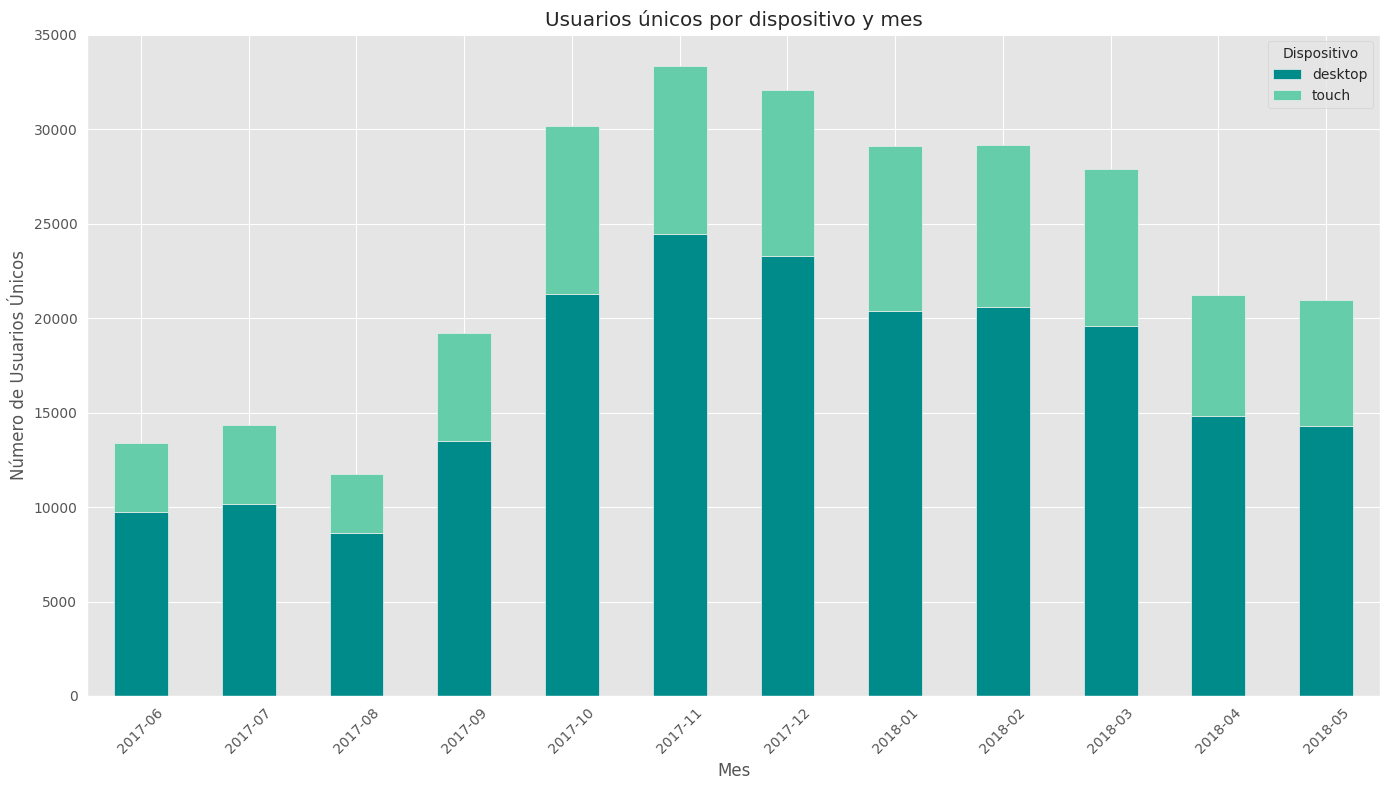

In [13]:
# Paso 3: Visualización.
# Crear gráficos para mostrar las métricas clave y cómo cambian con el tiempo.

def visualize_metrics(visits_df, orders_df, costs_df, romi_data, cac_data, ltv_table):
    """
    Genera gráficos para visualizar las métricas clave del negocio.

    Incluye la visualización de usuarios y sesiones a lo largo del tiempo,
    la distribución del tiempo de conversión, el LTV, CAC y ROMI por fuente.

    Args:
        visits_df (pd.DataFrame): DataFrame con los datos de visitas.
        orders_df (pd.DataFrame): DataFrame de pedidos.
        costs_df (pd.DataFrame): DataFrame de costos de marketing.
    """
    print("\n--- Visualización de métricas ---")

    # Configuración de gráficos
    sns.set_style('whitegrid')
    plt.style.use('ggplot')

    # 1. Gráfico de LTV acumulado por cohorte (líneas)
    plt.figure(figsize=(14, 8))
    ltv_table.index = ltv_table.index.astype(str)
    for col in ltv_table.columns:
        plt.plot(ltv_table.index, ltv_table[col], marker='o', label=f'Edad {col}')
    plt.title('Evolución del LTV Acumulado por Cohorte de Adquisición')
    plt.xlabel('Cohorte (Mes de primera compra)')
    plt.ylabel('LTV Acumulado ($)')
    plt.legend(title='Edad de la cohorte', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 2. Gráfico de usuarios y sesiones por mes
    sessions_per_month = visits_df.groupby(visits_df['start_ts'].dt.to_period('M'))['uid'].count()
    users_per_month = visits_df.groupby(visits_df['start_ts'].dt.to_period('M'))['uid'].nunique()
    
    plt.figure(figsize=(14, 6))
    sessions_per_month.plot(kind='bar', label='Sesiones', alpha=0.7, color='teal')
    users_per_month.plot(kind='bar', label='Usuarios Únicos', alpha=0.7, color='coral')
    plt.title('Número de Sesiones y Usuarios Únicos por Mes')
    plt.xlabel('Mes')
    plt.ylabel('Cantidad')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 3. Gráfico de barras de ROMI y CAC por fuente
    metrics_by_source = pd.merge(cac_data[['source_id', 'cac']], romi_data[['source_id', 'romi']], on='source_id')
    metrics_by_source = metrics_by_source.sort_values(by='romi', ascending=False)
    x = np.arange(len(metrics_by_source['source_id']))
    width = 0.35
    fig, ax1 = plt.subplots(figsize=(14, 8))
    color = 'tab:red'
    ax1.set_xlabel('Fuente de Adquisición (Source ID)')
    ax1.set_ylabel('ROMI', color=color)
    ax1.bar(x - width/2, metrics_by_source['romi'], width, label='ROMI', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_title('ROMI y CAC por Fuente de Adquisición', pad=20)
    ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('CAC', color=color)
    ax2.bar(x + width/2, metrics_by_source['cac'], width, label='CAC', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(x)
    ax1.set_xticklabels(metrics_by_source['source_id'])
    fig.tight_layout()
    plt.show()

    # 4. Gráfico de distribución del tiempo de conversión
    first_session = visits_df.groupby('uid')['start_ts'].min()
    first_order = orders_df.groupby('uid')['buy_ts'].min()
    conversion_time = (first_order - first_session).dt.days.dropna()
    
    plt.figure(figsize=(10, 6))
    sns.histplot(conversion_time, bins=30, kde=False, color='darkgreen')
    plt.title('Distribución del Tiempo de Conversión (Días)')
    plt.xlabel('Días hasta la primera compra')
    plt.ylabel('Cantidad de usuarios')
    plt.xlim(0, 30)
    plt.tight_layout()
    plt.show()

    # 5. Gráfico de LTV acumulado por cohorte (heatmap)
    orders_df['first_order_month'] = orders_df.groupby('uid')['buy_ts'].transform(lambda x: x.min().to_period('M'))
    orders_df['age'] = (orders_df['buy_ts'].dt.to_period('M') - orders_df['first_order_month']).apply(lambda x: x.n)
    
    cohorts = orders_df.groupby(['first_order_month', 'age']).agg(
        cohort_revenue=('revenue', 'sum')).reset_index()
    
    cohort_sizes = orders_df.groupby('first_order_month')['uid'].nunique()
    cohorts['cohort_size'] = cohorts['first_order_month'].map(cohort_sizes)
    cohorts['ltv'] = cohorts['cohort_revenue'] / cohorts['cohort_size']
    
    ltv_table_heatmap = cohorts.pivot_table(index='first_order_month', columns='age', values='ltv').cumsum(axis=1)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(ltv_table_heatmap, annot=True, fmt='.2f', cmap='viridis')
    plt.title('LTV (Lifetime Value) Acumulado por Cohorte de Adquisición')
    plt.xlabel('Edad de la cohorte (meses)')
    plt.ylabel('Cohorte (Mes de primera compra)')
    plt.tight_layout()
    plt.show()

    # 6. Usuarios únicos por dispositivo y mes
    visits_per_month_device = visits_df.groupby([visits_df['start_ts'].dt.to_period('M'), 'device'])['uid'].nunique().reset_index()
    visits_per_month_device['month'] = visits_per_month_device['start_ts'].astype(str)
    
    # Pivotar la tabla para el gráfico de barras apiladas
    pivot_df = visits_per_month_device.pivot_table(index='month', columns='device', values='uid', aggfunc='sum')

    plt.figure(figsize=(14, 8))
    pivot_df.plot(kind='bar', stacked=True, figsize=(14, 8), color=['darkcyan', 'mediumaquamarine'])
    plt.title('Usuarios únicos por dispositivo y mes')
    plt.xlabel('Mes')
    plt.ylabel('Número de Usuarios Únicos')
    plt.xticks(rotation=45)
    plt.legend(title='Dispositivo')
    plt.tight_layout()
    plt.show()
    

# Llamada a las funciones de análisis y visualización
if visits_log is not None and orders_log is not None and costs is not None:
    analyze_visits(visits_log)
    ltv_table = analyze_sales(visits_log, orders_log)
    romi_data, cac_data = analyze_marketing(costs, visits_log, orders_log)
    visualize_metrics(visits_log, orders_log, costs, romi_data, cac_data, ltv_table)

### Paso 4: Conclusiones y Recomendaciones Clave

El negocio tiene un **crecimiento y una retención de clientes saludables**, pero la rentabilidad general se ve comprometida por una **estrategia de marketing ineficiente** que no está alineada con el comportamiento de los usuarios en diferentes dispositivos.

**Análisis detallado:**

**Crecimiento:** El número de sesiones y usuarios únicos se ha mantenido en una tendencia ascendente, aunque con fluctuaciones mensuales. Esto indica una adquisición de clientes estable.

**Retención y Conversión:** El tiempo de conversión es muy rápido, ya que la gran mayoría de las compras se realizan en los primeros 10 días, lo que sugiere una alta efectividad en la conversión inicial. La gráfica de LTV muestra que algunas cohortes (especialmente la de septiembre de 2017) tienen un rendimiento excepcional y mantienen su valor a lo largo del tiempo, lo que demuestra una buena retención de estos clientes de alto valor.

**Rentabilidad (ROMI y CAC):** La inversión en marketing no es uniforme. Las fuentes 3, 4 y 10 tienen un ROMI negativo, lo que significa que están perdiendo dinero. Por otro lado, las fuentes 1, 2 y 9 son rentables, con la fuente 1 teniendo un ROMI muy alto y un CAC bajo.

**Comportamiento por Dispositivo:** El análisis por dispositivo revela una dominancia del tráfico de escritorio (desktop) sobre el tráfico móvil (touch). Aunque la mayoría de los usuarios provienen de escritorio, es crucial investigar si las conversiones y el LTV son diferentes en cada tipo de dispositivo. Una mayor inversión en móvil podría ser necesaria si los usuarios de este canal tienen un LTV o una tasa de conversión más alta.

**Recomendaciones:**

* **Reasignar el presupuesto:** Se debe **detener la inversión en las fuentes con ROMI negativo (3, 4 y 10)**. El dinero debe ser redirigido a las fuentes que demuestran ser rentables (1, 2 y 9). La prioridad debe ser la **fuente 1** debido a su bajo CAC y su alto ROMI.

* **Análisis del LTV por Fuente:** Se recomienda realizar un análisis más profundo para calcular el LTV específico por cada fuente de adquisición. Esto ayudará a validar si las fuentes con CAC más alto, como la fuente 2, realmente valen la pena a largo plazo.

* **Optimización para Dispositivos:** Investiga las tasas de conversión y el LTV de los usuarios de escritorio y móviles. Si el rendimiento del tráfico móvil es bueno, se debe considerar una estrategia de marketing enfocada en este canal para captar un mayor volumen de usuarios, o bien, optimizar la experiencia de usuario para mejorar la conversión en dispositivos móviles.

### Cuestionario del Proyecto:

📊 **Visitas**

**¿Cuántas personas lo usan y cuántas sesiones hay?**

* Diariamente: El 1 de junio de 2017, hubo `664` sesiones y `605` usuarios únicos.
* Semanalmente: En la primera semana completa (del 5 al 11 de junio de 2017), hubo `4,129` usuarios únicos.
* Mensualmente: El número de usuarios únicos fue creciendo de `13,259` en junio de 2017 a `29,692` en octubre de 2017.

**¿Cuál es la duración de cada sesión?**
* La duración promedio de la sesión es de `10.72` minutos.

**¿Con qué frecuencia los usuarios regresan?**
* La tabla de LTV y el análisis de conversión sugieren que los usuarios que compraron en junio de 2017 continuaron generando ingresos durante los siguientes 11 meses. Sin embargo, la mayor parte de las conversiones `(90%)` ocurrieron el mismo día de la primera visita, lo que indica que, si bien algunos usuarios regresan, la primera sesión es la más crítica para la conversión inicial.

**¿Qué porcentaje de los usuarios visitan la página desde un dispositivo móvil?**

* A lo largo de los meses analizados, aproximadamente el 65% del tráfico total proviene de dispositivos de escritorio (desktop), mientras que el 35% restante proviene de dispositivos móviles (touch). El tráfico de escritorio domina consistentemente, aunque la proporción móvil ha ido aumentando ligeramente con el tiempo.


🛒 **Ventas**

**¿Cuándo empieza la gente a comprar?**
* La mayoría de los usuarios compran el mismo día de su primera visita (etiquetada como 'Conversion 0d'), con `26,363` usuarios realizando una compra en el `día 0`. A partir del día 1, la cantidad de conversiones disminuye drásticamente.

**¿Cuántos pedidos hacen y cuál es el tamaño promedio de compra?**
* Los pedidos varían diariamente, pero el tamaño promedio de compra se mantiene relativamente bajo. Por ejemplo, el 1 de junio de 2017, se realizaron 96 pedidos con un tamaño promedio de compra de `$4.06`.

**¿Cuánto dinero traen? (LTV)**
* El LTV (Valor de Vida del Cliente) muestra que los clientes de la cohorte de junio de 2017 han generado un ingreso acumulado promedio de `$11.88` por usuario después de 11 meses. Las cohortes de los meses siguientes también muestran un crecimiento constante en el LTV.


📈 **Marketing**

**¿Cuánto dinero se gastó?**
* Total: Se gastó un total de `$329,131.62`.
* Por fuente: La fuente con ID 3 recibió la mayor inversión con `$141,321.63`.
* A lo largo del tiempo: Los costos varían, pero el análisis se enfoca en la inversión por fuente para determinar la rentabilidad.

**¿Cuál fue el costo de adquisición de clientes (CAC) de cada una de las fuentes?**
* El CAC más alto fue de `$2.25` para la fuente ID 3, mientras que el más bajo fue de `$0.81` para la fuente ID 9.

**¿Cuán rentables eran las inversiones? (ROMI)**
* La inversión en marketing fue ineficiente en general.
* ROMI Positivo: Las fuentes ID 1, 2 y 9 fueron rentables con ROMI de `0.85`, `0.52` y `0.28` respectivamente.
* ROMI Negativo: La mayoría de las fuentes tuvieron un retorno negativo. La fuente ID 3 fue la menos rentable con un ROMI de `-0.69`, lo que indica que por cada dólar invertido se perdió dinero.